In [ ]:
# Cell 1 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f9fa"
plt.rcParams["axes.grid"]        = True
plt.rcParams["grid.alpha"]       = 0.3
plt.rcParams["font.family"]      = "Arial"

CELL_COL = "CO_DN"

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

# Your 5 core KPIs with thresholds
KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate (%)",
        "threshold": 0.5,
        "direction": "high",
        "color"    : "#C00000",
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR (%)",
        "threshold": 99.5,
        "direction": "low",
        "color"    : "#2E75B6",
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR (%)",
        "threshold": 99.5,
        "direction": "low",
        "color"    : "#70AD47",
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "threshold": 7.0,
        "direction": "low",
        "color"    : "#FF8C00",
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr (Mbps)",
        "threshold": 3.0,
        "direction": "low",
        "color"    : "#7030A0",
    },
]

KPI_COLS   = [k["col"]   for k in KPI_CONFIG]
KPI_LABELS = [k["label"] for k in KPI_CONFIG]

print("✅ Setup done")
print(f"   Tracking {len(KPI_CONFIG)} KPIs")

✅ Setup done
   Tracking 5 KPIs


In [2]:
# Cell 2 – Load cleaned data
import pyxlsb

CSV_PATH     = "../data/cleaned_master_data.csv"
RAW_FILE     = "../data/4G raw KPI Cell wise17th_June'26.xlsb"

df = pd.read_csv(CSV_PATH)

# Ensure Short_Cell exists
if "Short_Cell" not in df.columns:
    df["Short_Cell"] = df[CELL_COL].apply(short_cell_name)

# Convert KPIs to numeric
for col in KPI_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Get sheet names for day ordering
with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets

print(f"Data shape        : {df.shape}")
print(f"Unique cells      : {df['Short_Cell'].nunique()}")
print(f"Days              : {df['Day'].nunique()}")
print(f"\nKPIs available:")
for cfg in KPI_CONFIG:
    exists = "✅" if cfg["col"] in df.columns else "❌"
    print(f"  {exists}  {cfg['label']}")

Data shape        : (842125, 97)
Unique cells      : 51359
Days              : 17

KPIs available:
  ✅  Drop Rate (%)
  ✅  E2E CSSR (%)
  ✅  VoLTE CSSR (%)
  ✅  CQI
  ✅  Avg Thpr (Mbps)


In [3]:
# Cell 3 – Descriptive statistics for all 5 KPIs

kpi_present = [c for c in KPI_COLS if c in df.columns]

stats = df[kpi_present].describe().T
stats.index = [
    cfg["label"] for cfg in KPI_CONFIG
    if cfg["col"] in kpi_present
]
stats = stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
stats = stats.round(3)

print("KPI Descriptive Statistics\n")
print(stats.to_string())

print("\n\nThreshold Breach Summary:")
print(f"{'KPI':<20} {'Threshold':>12} {'Breaching':>12} {'Breach %':>10}")
print("-" * 58)

for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce").dropna()
    if cfg["direction"] == "high":
        breaching = (numeric > cfg["threshold"]).sum()
    else:
        breaching = (numeric < cfg["threshold"]).sum()
    pct = round(breaching / len(numeric) * 100, 1)
    print(f"  {cfg['label']:<18} {cfg['threshold']:>12} "
          f"{breaching:>12,} {pct:>9.1f}%")

KPI Descriptive Statistics

                    count    mean    std   min    25%    50%     75%     max
Drop Rate (%)    842125.0   0.218  0.469  0.00   0.08   0.14    0.25  100.00
E2E CSSR (%)     842125.0  99.558  1.620  0.06  99.54  99.78   99.89  165.35
VoLTE CSSR (%)   842125.0  99.633  3.224  0.00  99.68  99.87  100.00  101.23
CQI              842125.0   9.613  1.393  0.09   8.68   9.55   10.54   14.82
Avg Thpr (Mbps)  842125.0  10.073  5.494  0.02   5.96   9.34   13.32   82.15


Threshold Breach Summary:
KPI                     Threshold    Breaching   Breach %
----------------------------------------------------------
  Drop Rate (%)               0.5       52,045       6.2%
  E2E CSSR (%)               99.0       67,495       8.0%
  VoLTE CSSR (%)             99.0       35,742       4.2%
  CQI                         7.0       21,649       2.6%
  Avg Thpr (Mbps)             3.0       60,799       7.2%


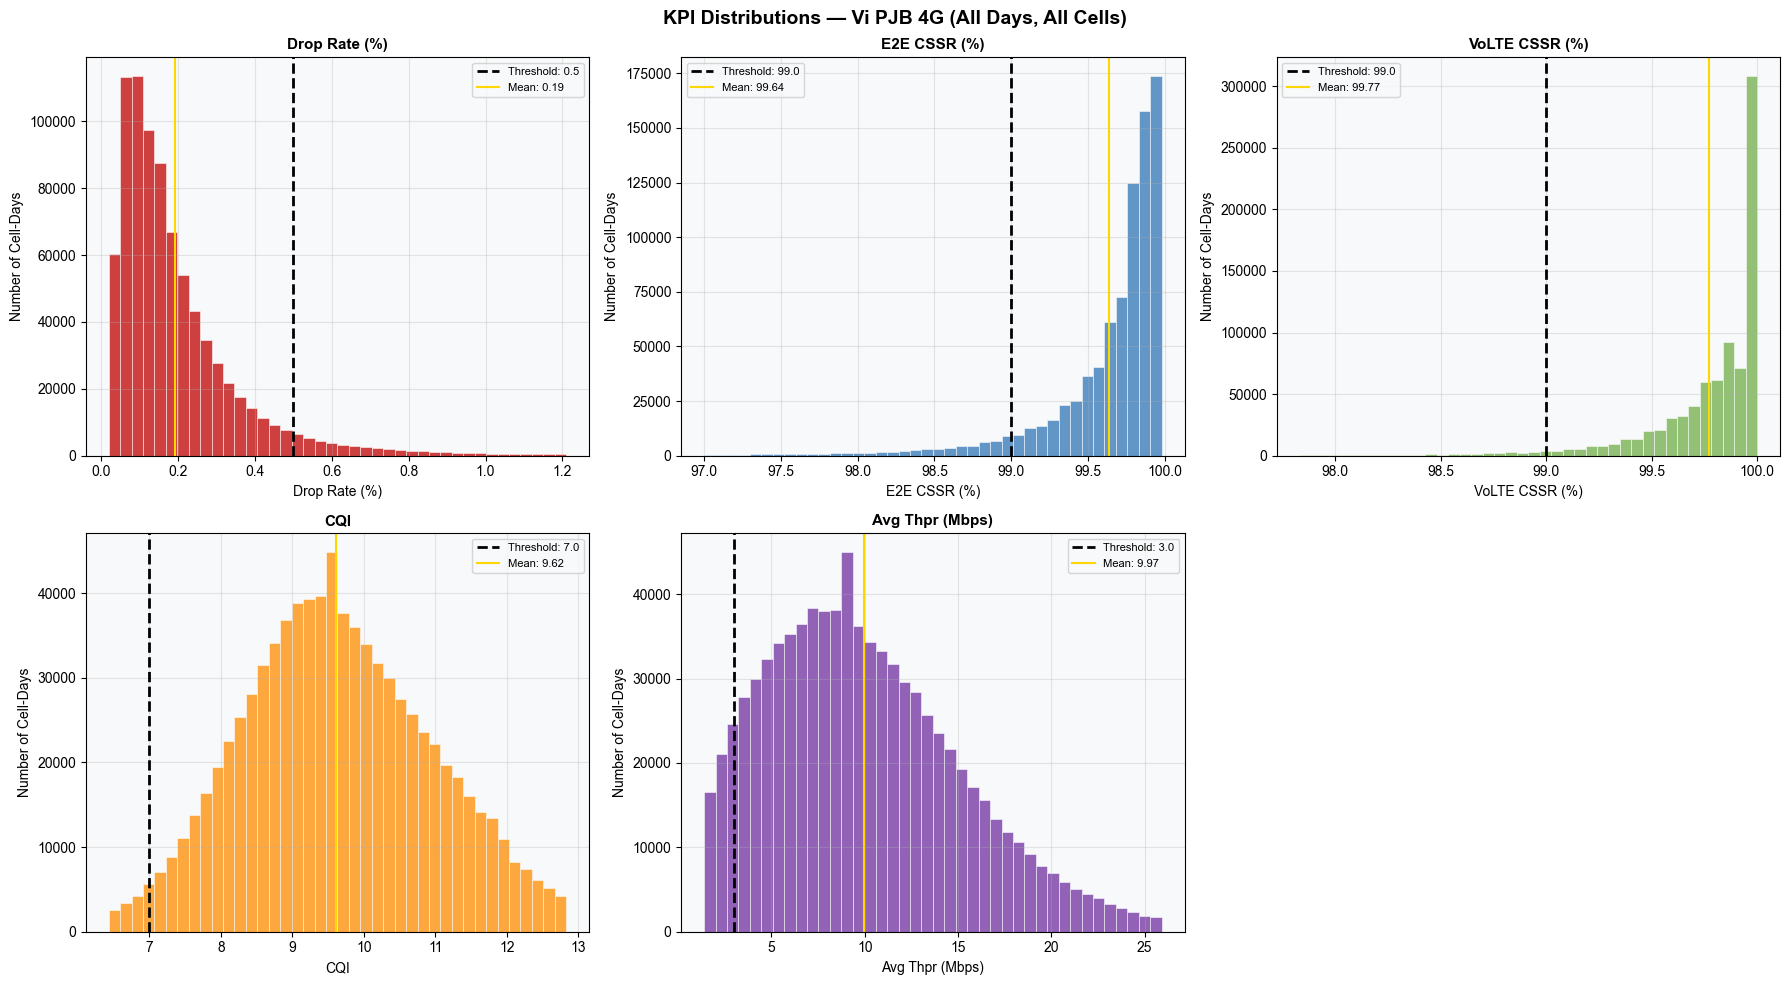

✅ Saved → outputs/eda_kpi_distributions.png


In [4]:
# Cell 4 – Distribution of each KPI with threshold line

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("KPI Distributions — Vi PJB 4G (All Days, All Cells)",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, cfg in enumerate(KPI_CONFIG):
    col = cfg["col"]
    ax  = axes[i]

    if col not in df.columns:
        ax.set_visible(False)
        continue

    data = pd.to_numeric(df[col], errors="coerce").dropna()

    # Remove extreme outliers for better visualisation
    q99  = data.quantile(0.99)
    q01  = data.quantile(0.01)
    data = data[(data >= q01) & (data <= q99)]

    ax.hist(data, bins=40, color=cfg["color"],
            alpha=0.75, edgecolor="white", linewidth=0.5)

    # Threshold line
    ax.axvline(cfg["threshold"], color="black",
               linestyle="--", linewidth=2,
               label=f"Threshold: {cfg['threshold']}")

    # Mean line
    ax.axvline(data.mean(), color="#FFD700",
               linestyle="-", linewidth=1.5,
               label=f"Mean: {data.mean():.2f}")

    ax.set_title(cfg["label"], fontweight="bold", fontsize=11)
    ax.set_xlabel(cfg["label"])
    ax.set_ylabel("Number of Cell-Days")
    ax.legend(fontsize=8)

# Hide last unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/eda_kpi_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/eda_kpi_distributions.png")

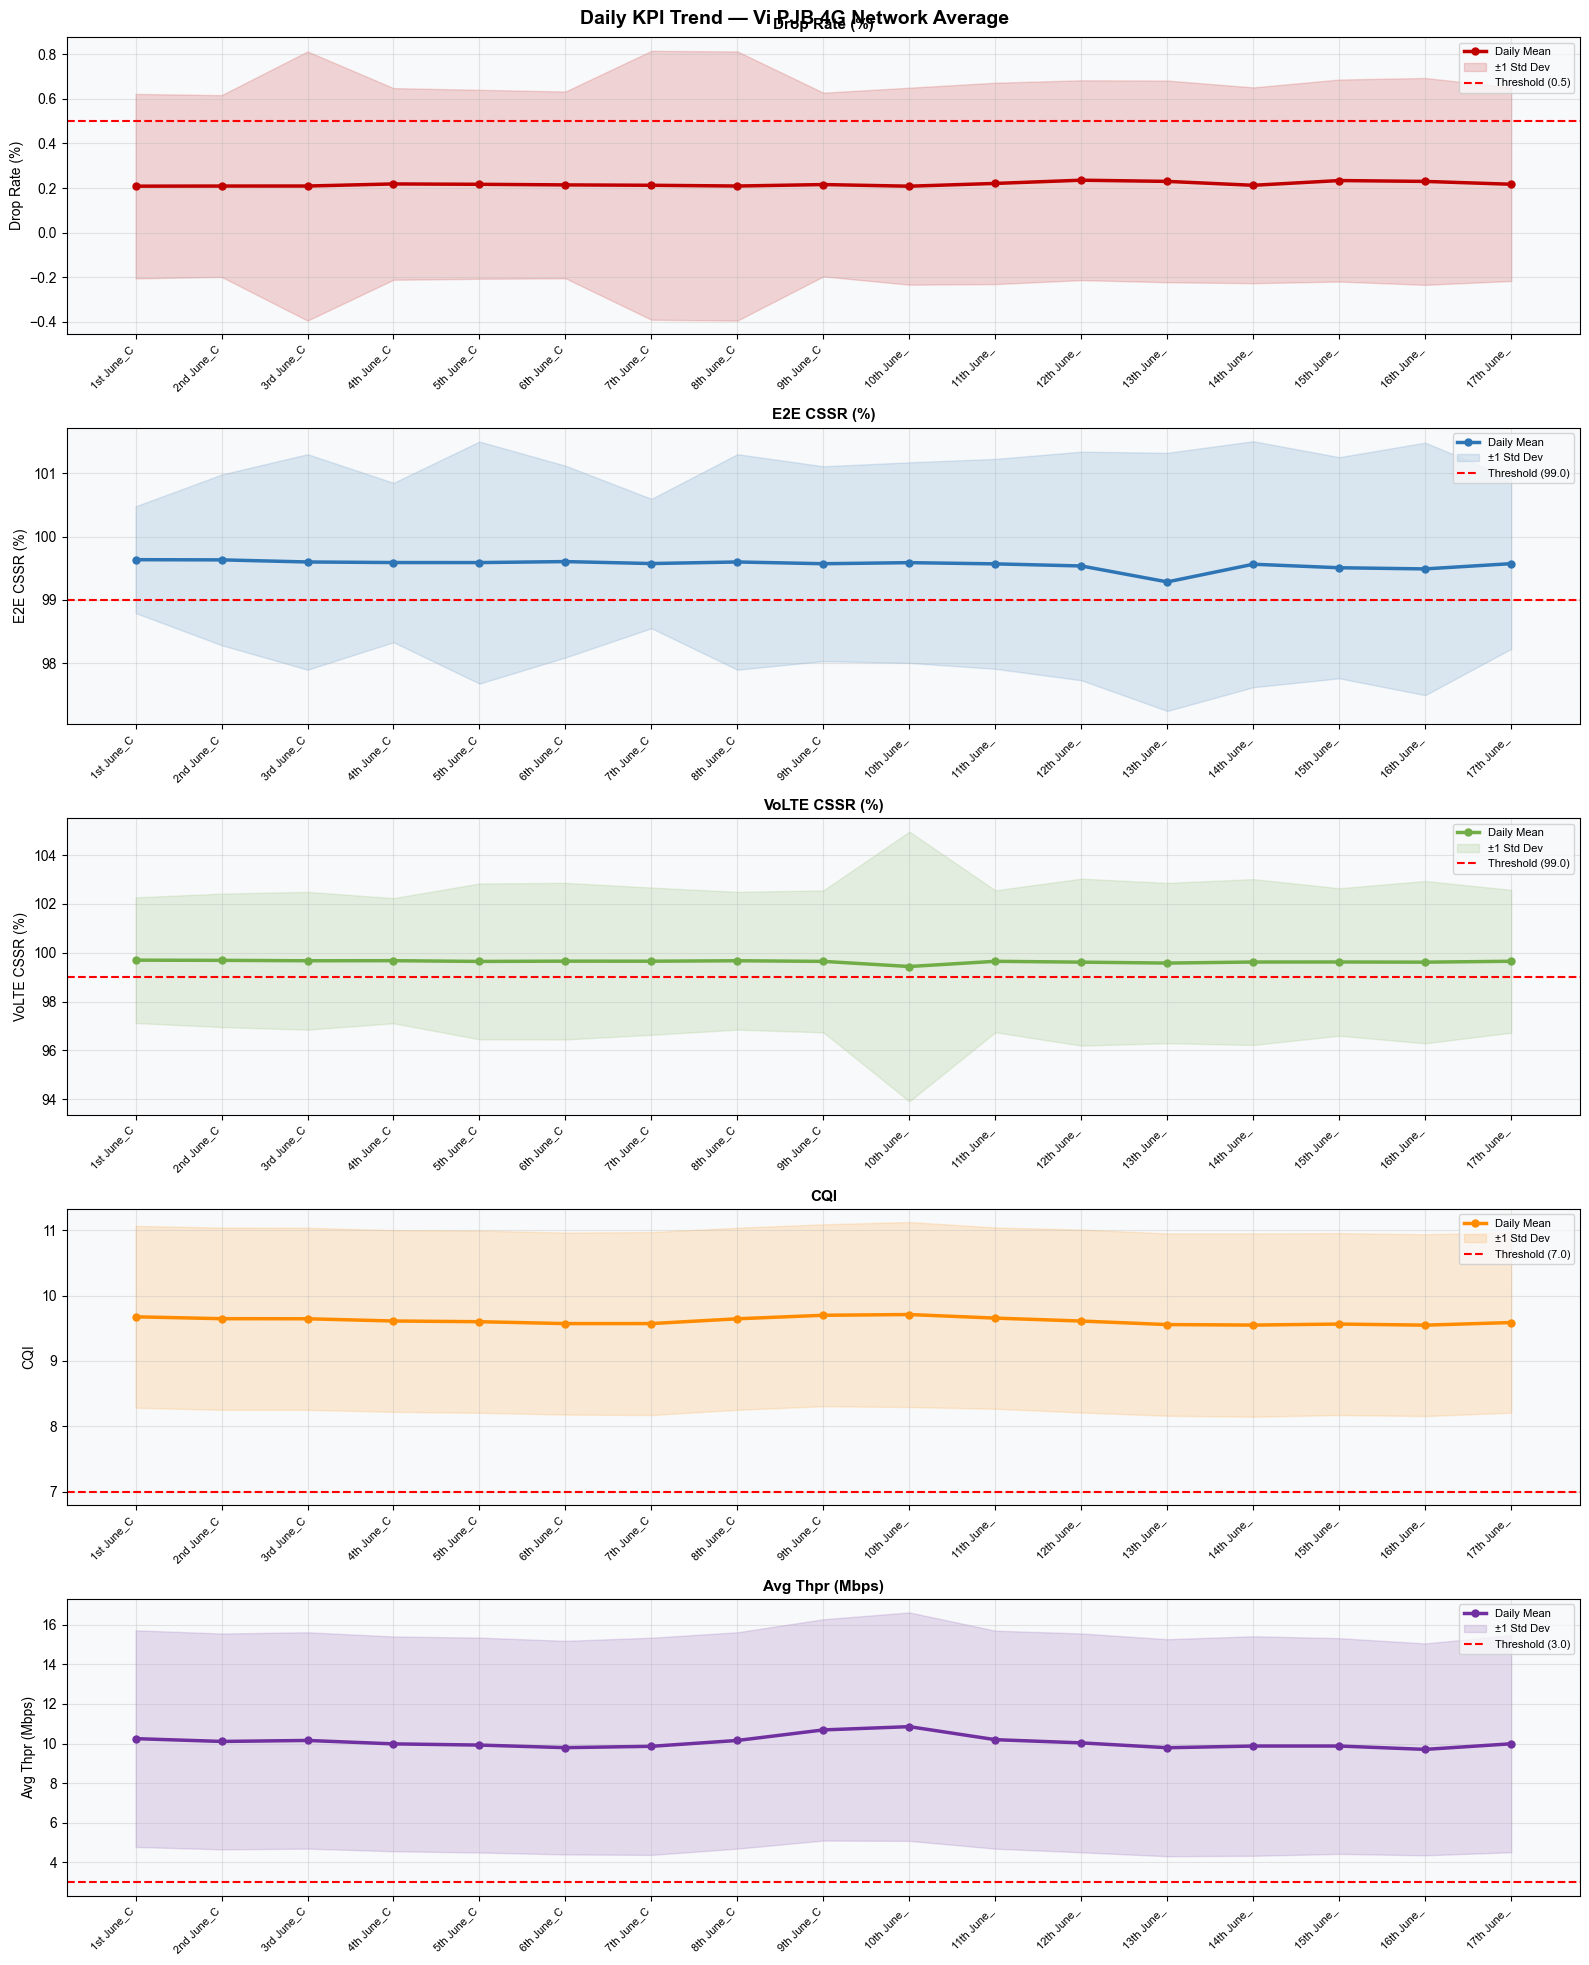

✅ Saved → outputs/eda_daily_kpi_trend.png


In [5]:
# Cell 5 – How each KPI changes across 17 days (network average)

# Map day names to order
day_order = {day: i for i, day in enumerate(sheet_names)}
df["Day_Index"] = df["Day"].map(day_order)
df_sorted = df.sort_values("Day_Index")

fig, axes = plt.subplots(len(KPI_CONFIG), 1, figsize=(16, 4*len(KPI_CONFIG)))
fig.suptitle("Daily KPI Trend — Vi PJB 4G Network Average",
             fontsize=14, fontweight="bold")

for ax, cfg in zip(axes, KPI_CONFIG):
    col = cfg["col"]
    if col not in df.columns:
        continue

    daily = (df_sorted.groupby("Day")[col]
             .agg(["mean", "std"])
             .reindex(sheet_names))

    x = range(len(sheet_names))

    # Mean line
    ax.plot(x, daily["mean"].values,
            color=cfg["color"], linewidth=2.5,
            marker="o", markersize=5, label="Daily Mean")

    # Std band
    ax.fill_between(
        x,
        daily["mean"].values - daily["std"].values,
        daily["mean"].values + daily["std"].values,
        alpha=0.15, color=cfg["color"], label="±1 Std Dev"
    )

    # Threshold
    ax.axhline(cfg["threshold"], color="red",
               linestyle="--", linewidth=1.5,
               label=f"Threshold ({cfg['threshold']})")

    ax.set_xticks(x)
    ax.set_xticklabels(
        [s[:10] for s in sheet_names],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_title(cfg["label"], fontweight="bold", fontsize=11)
    ax.set_ylabel(cfg["label"])
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/eda_daily_kpi_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/eda_daily_kpi_trend.png")

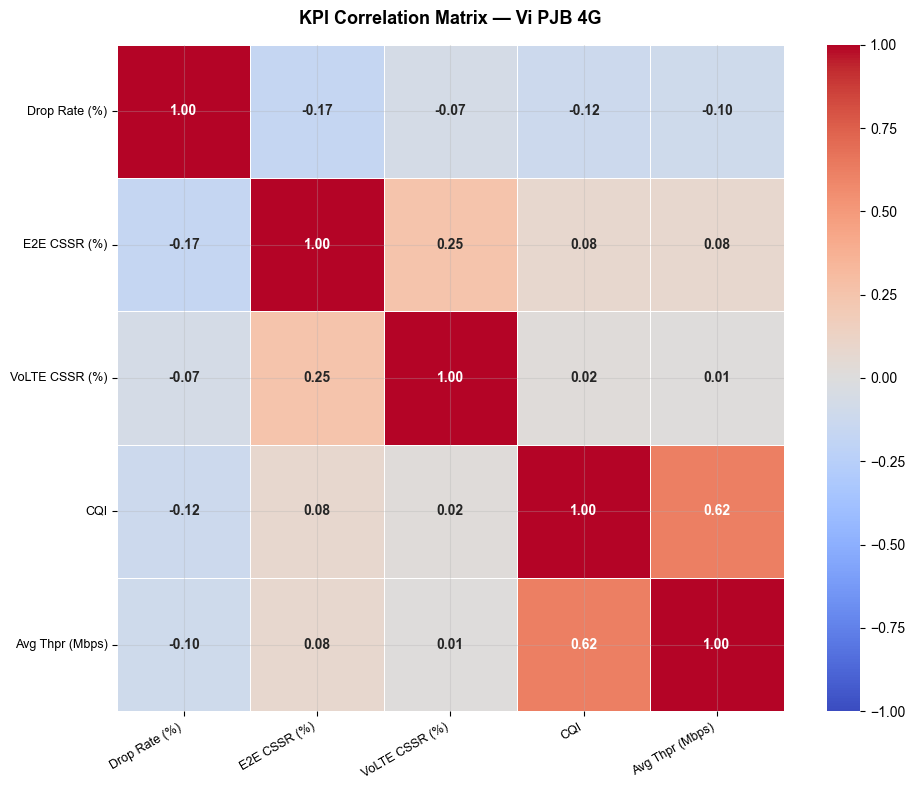

Strongest KPI correlations:

          KPI 1         KPI 2  Correlation
Avg Thpr (Mbps)           CQI     0.618985
 VoLTE CSSR (%)  E2E CSSR (%)     0.251912
   E2E CSSR (%) Drop Rate (%)    -0.169296
            CQI Drop Rate (%)    -0.124030
Avg Thpr (Mbps) Drop Rate (%)    -0.101616
            CQI  E2E CSSR (%)     0.082994
Avg Thpr (Mbps)  E2E CSSR (%)     0.080133
 VoLTE CSSR (%) Drop Rate (%)    -0.069764


In [6]:
# Cell 6 – KPI correlation matrix
# Shows which KPIs move together
# High correlation = one KPI predicts another

kpi_present = [c for c in KPI_COLS if c in df.columns]
corr_df     = df[kpi_present].apply(
    pd.to_numeric, errors="coerce"
).dropna()

corr_matrix = corr_df.corr()
corr_matrix.index   = KPI_LABELS[:len(kpi_present)]
corr_matrix.columns = KPI_LABELS[:len(kpi_present)]

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = ".2f",
    cmap       = "coolwarm",
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    square     = True,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {"size": 10, "weight": "bold"}
)

ax.set_title("KPI Correlation Matrix — Vi PJB 4G",
             fontweight="bold", fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/eda_kpi_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print strongest correlations
print("Strongest KPI correlations:\n")
corr_pairs = (corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["KPI 1", "KPI 2", "Correlation"]
corr_pairs["Abs"]  = corr_pairs["Correlation"].abs()
top_corr = corr_pairs.sort_values("Abs", ascending=False).head(8)
print(top_corr[["KPI 1","KPI 2","Correlation"]].to_string(index=False))


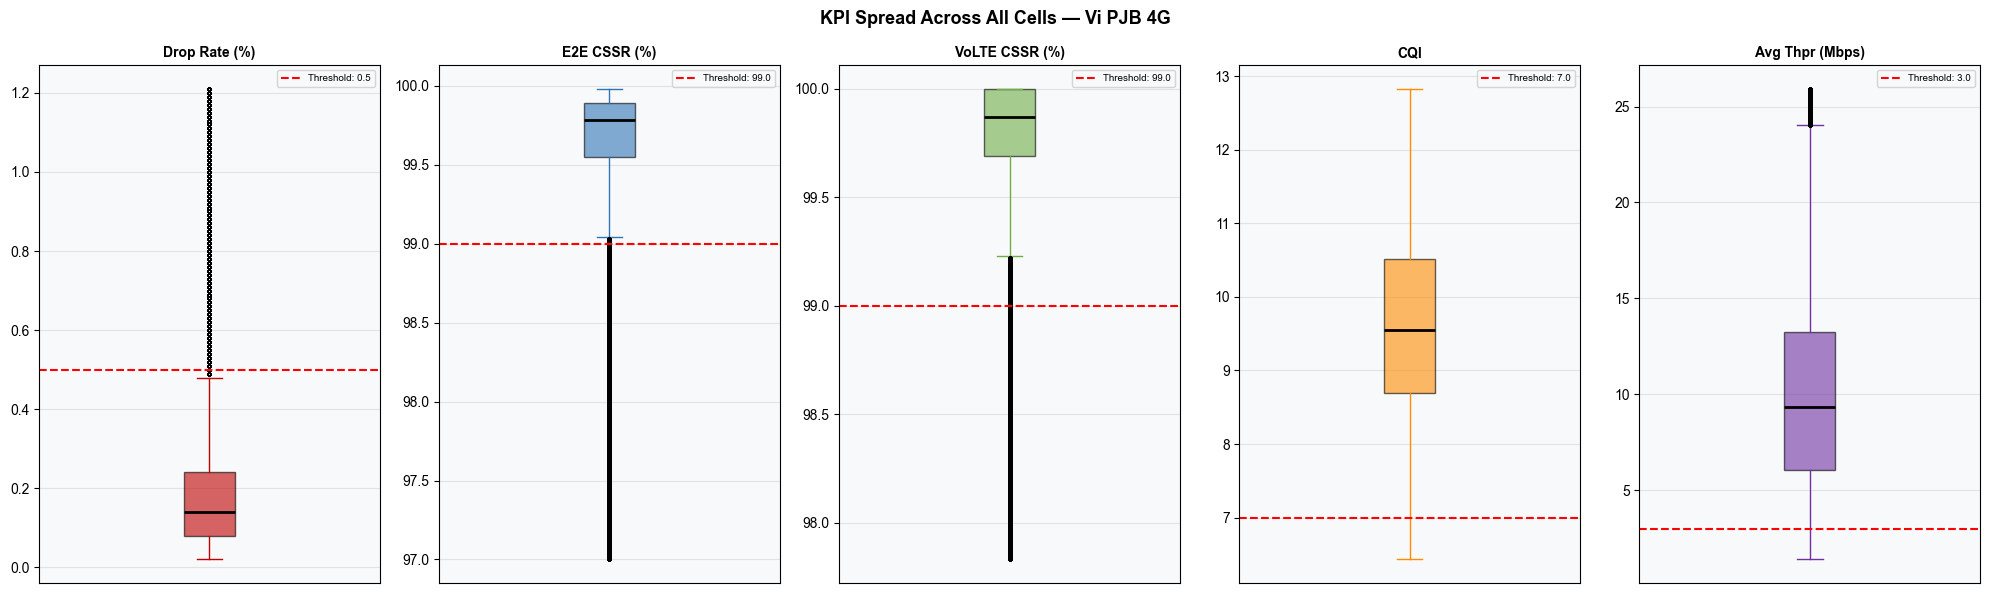

✅ Saved → outputs/eda_kpi_boxplots.png


In [7]:
# Cell 7 – Boxplot: spread of each KPI across all cells
# Shows which KPI has the most variance

fig, axes = plt.subplots(1, len(KPI_CONFIG),
                          figsize=(20, 6))
fig.suptitle("KPI Spread Across All Cells — Vi PJB 4G",
             fontsize=13, fontweight="bold")

for ax, cfg in zip(axes, KPI_CONFIG):
    col = cfg["col"]
    if col not in df.columns:
        continue

    data = pd.to_numeric(df[col], errors="coerce").dropna()
    q99  = data.quantile(0.99)
    q01  = data.quantile(0.01)
    data = data[(data >= q01) & (data <= q99)]

    ax.boxplot(
        data,
        patch_artist = True,
        boxprops     = dict(facecolor=cfg["color"], alpha=0.6),
        medianprops  = dict(color="black", linewidth=2),
        whiskerprops = dict(color=cfg["color"]),
        capprops     = dict(color=cfg["color"]),
        flierprops   = dict(marker="o", markersize=2,
                            alpha=0.3, color=cfg["color"])
    )
    ax.axhline(cfg["threshold"], color="red",
               linestyle="--", linewidth=1.5,
               label=f"Threshold: {cfg['threshold']}")
    ax.set_title(cfg["label"], fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../outputs/eda_kpi_boxplots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/eda_kpi_boxplots.png")

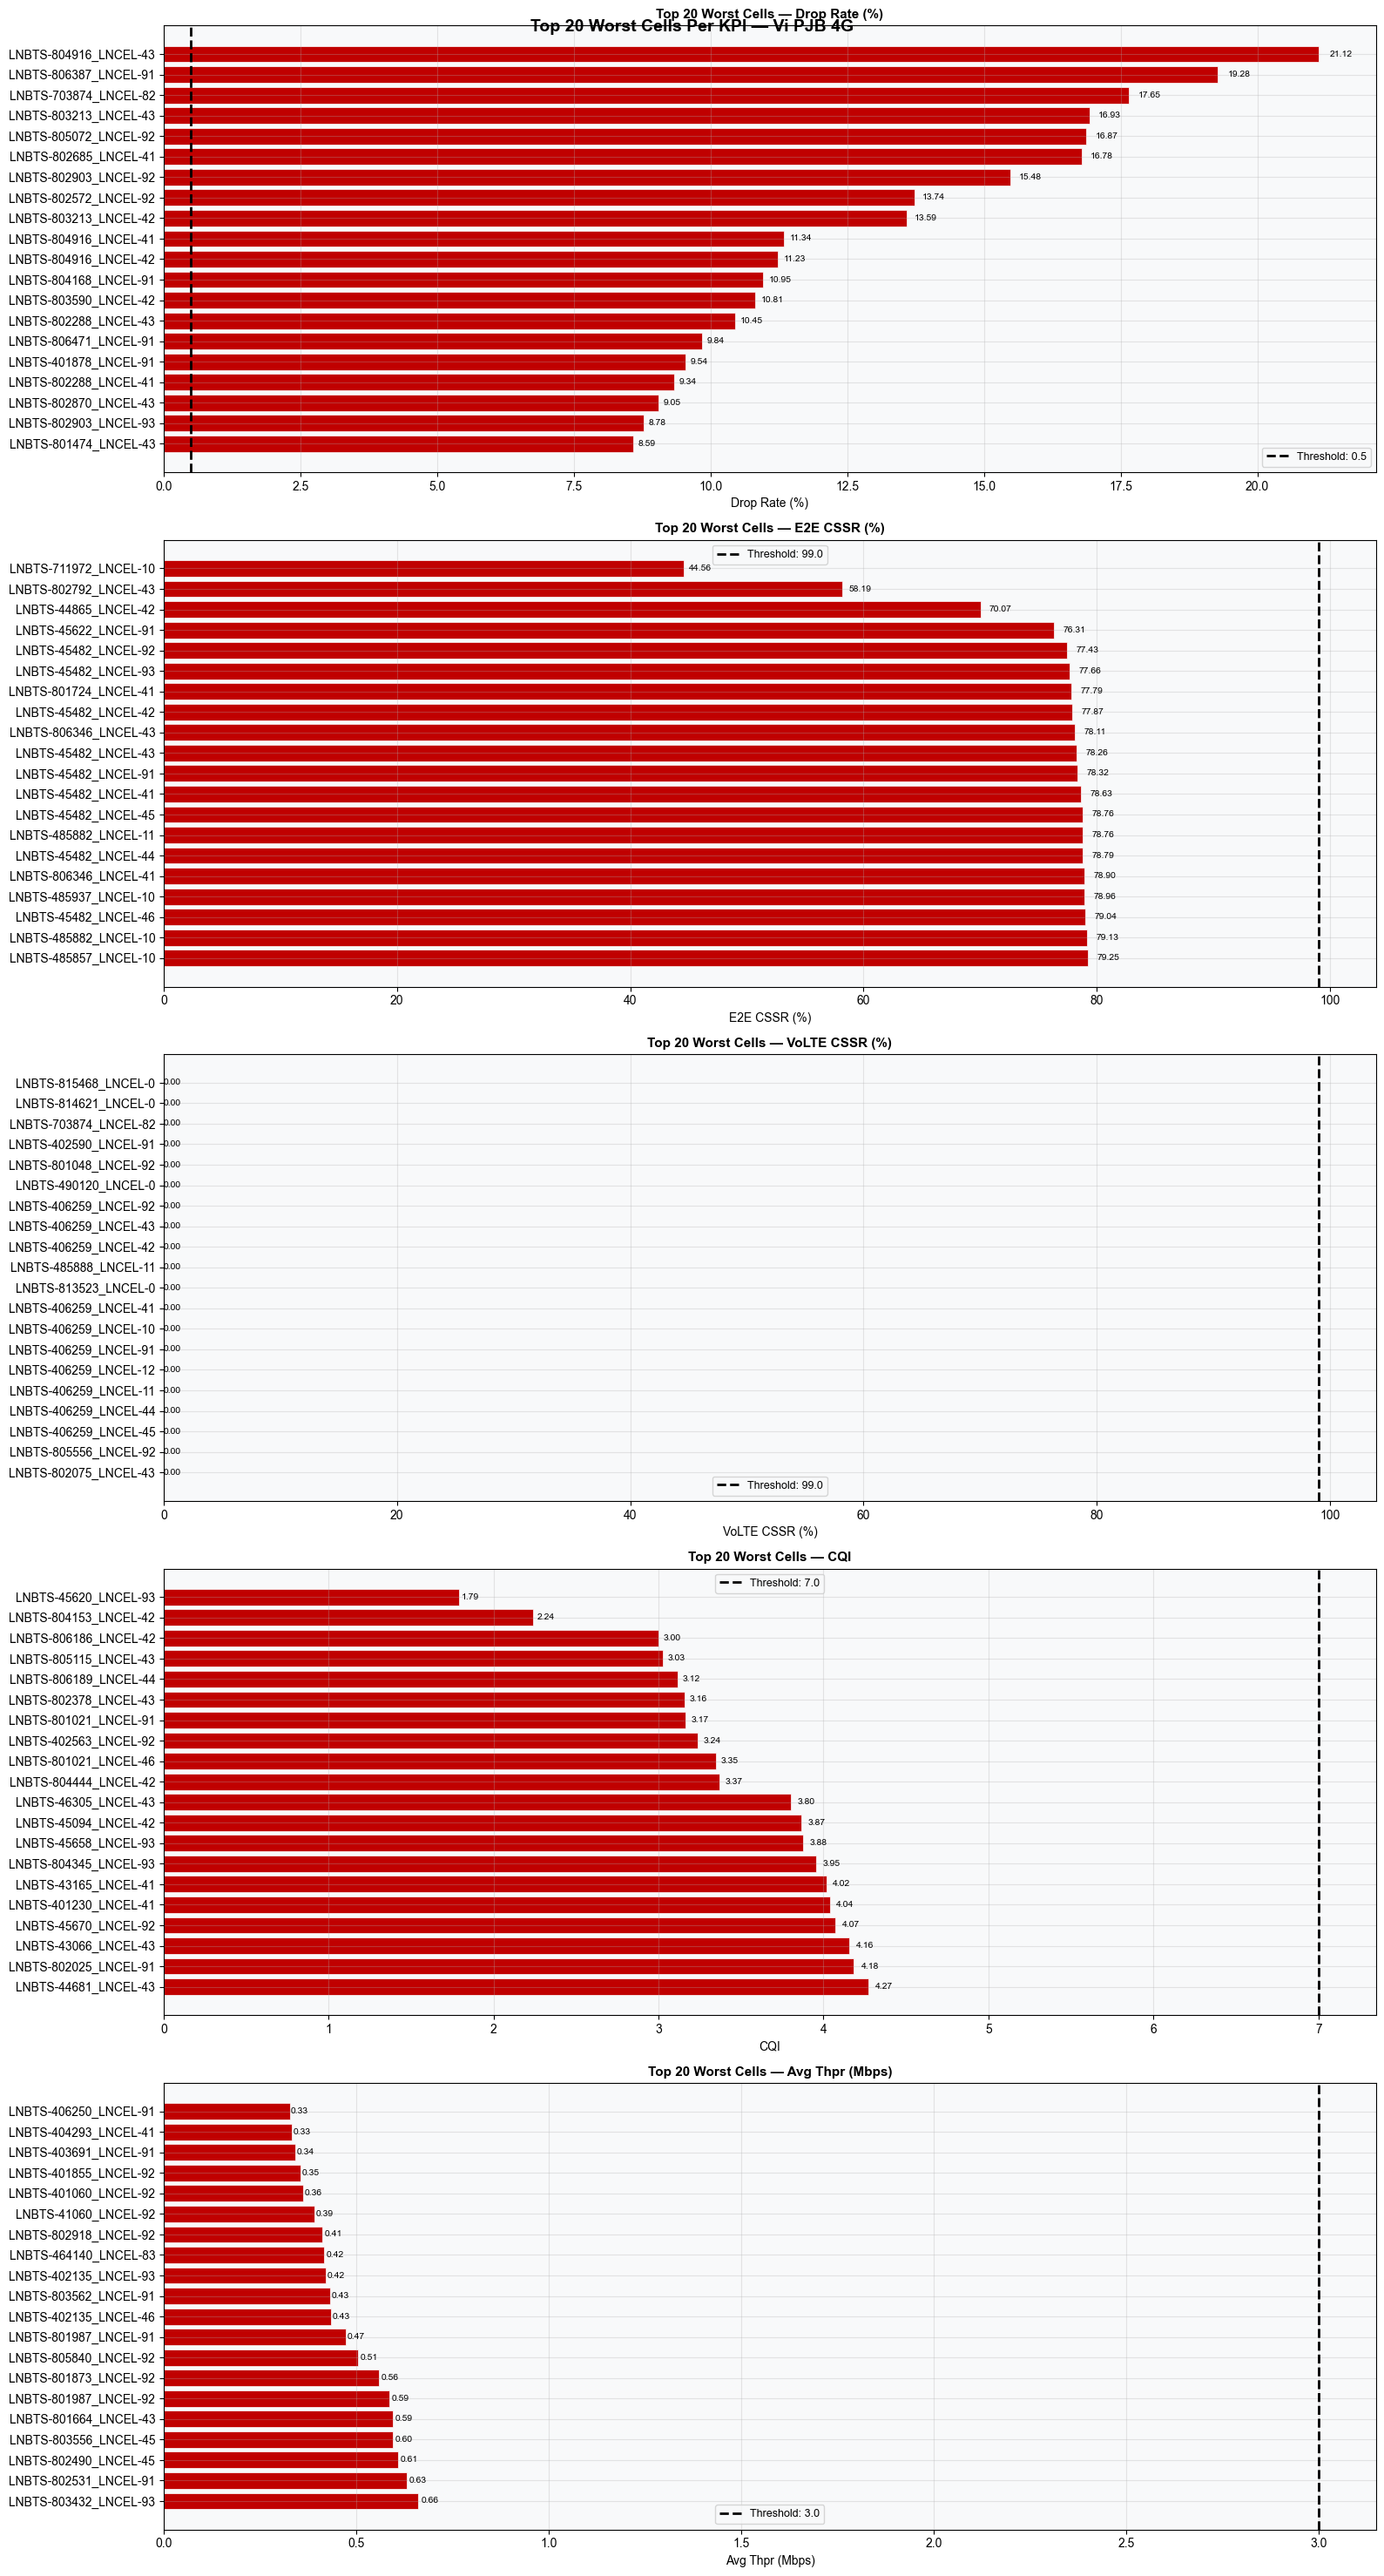

✅ Saved → outputs/eda_worst_cells_per_kpi.png


In [8]:
# Cell 8 – Top 20 worst cells per KPI (using Short_Cell)

fig, axes = plt.subplots(len(KPI_CONFIG), 1,
                          figsize=(16, 6*len(KPI_CONFIG)))
fig.suptitle("Top 20 Worst Cells Per KPI — Vi PJB 4G",
             fontsize=14, fontweight="bold")

for ax, cfg in zip(axes, KPI_CONFIG):
    col = cfg["col"]
    if col not in df.columns:
        continue

    df[col] = pd.to_numeric(df[col], errors="coerce")

    if cfg["direction"] == "high":
        # Worst = highest drop rate
        worst = (df.groupby("Short_Cell")[col]
                 .mean()
                 .sort_values(ascending=False)
                 .head(20)
                 .reset_index())
    else:
        # Worst = lowest CSSR/CQI/Thpr
        worst = (df.groupby("Short_Cell")[col]
                 .mean()
                 .sort_values(ascending=True)
                 .head(20)
                 .reset_index())

    colors = [
        "#C00000" if (
            (cfg["direction"] == "high" and v > cfg["threshold"]) or
            (cfg["direction"] == "low"  and v < cfg["threshold"])
        ) else "#2E75B6"
        for v in worst[col]
    ]

    bars = ax.barh(
        worst["Short_Cell"][::-1],
        worst[col][::-1],
        color=colors[::-1],
        edgecolor="white", linewidth=0.5
    )

    ax.axvline(cfg["threshold"], color="black",
               linestyle="--", linewidth=2,
               label=f"Threshold: {cfg['threshold']}")

    for bar, val in zip(bars, worst[col][::-1]):
        ax.text(bar.get_width() + abs(bar.get_width()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=7.5)

    ax.set_title(f"Top 20 Worst Cells — {cfg['label']}",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel(cfg["label"])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/eda_worst_cells_per_kpi.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/eda_worst_cells_per_kpi.png")

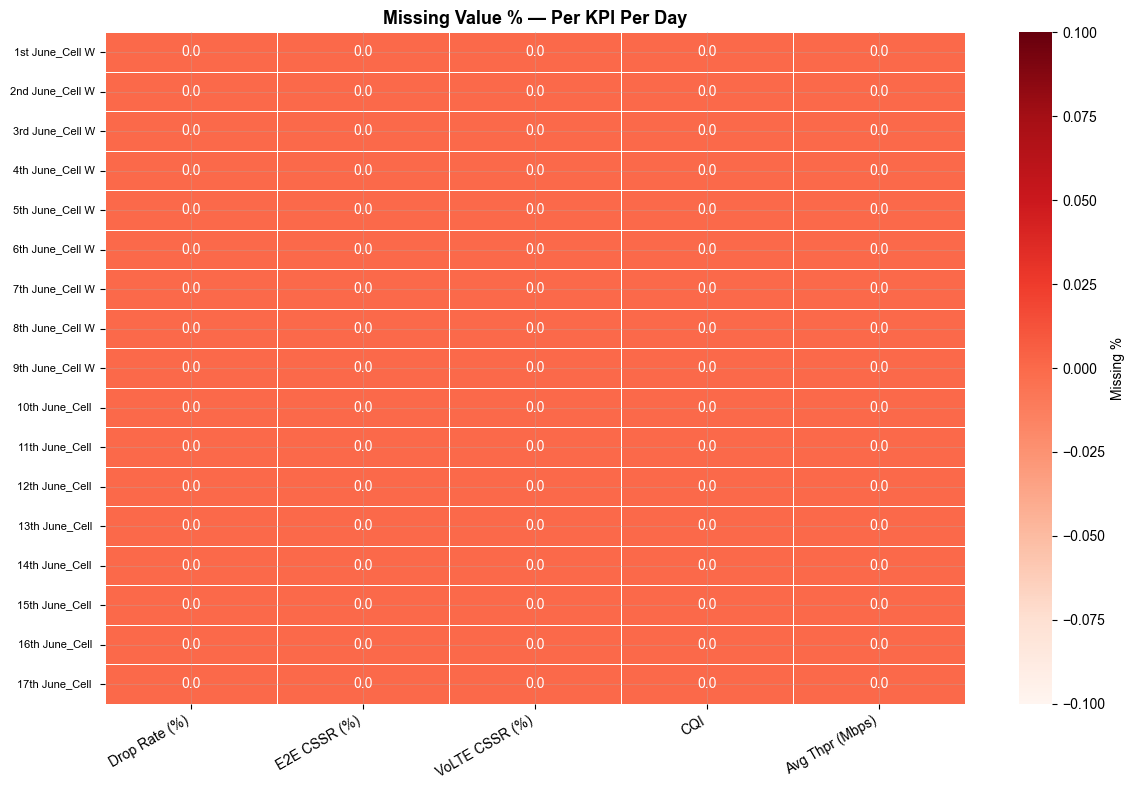

✅ Saved → outputs/eda_missing_values.png


In [9]:
# Cell 9 – Missing value heatmap per KPI per day

kpi_present = [c for c in KPI_COLS if c in df.columns]
labels      = [cfg["label"] for cfg in KPI_CONFIG
               if cfg["col"] in kpi_present]

missing_matrix = pd.DataFrame(index=sheet_names, columns=labels)

for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    for day in sheet_names:
        day_data  = df[df["Day"] == day][col]
        miss_pct  = day_data.isnull().mean() * 100
        missing_matrix.loc[day, cfg["label"]] = round(miss_pct, 1)

missing_matrix = missing_matrix.apply(pd.to_numeric, errors="coerce")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    missing_matrix,
    annot     = True,
    fmt       = ".1f",
    cmap      = "Reds",
    linewidths= 0.5,
    ax        = ax,
    cbar_kws  = {"label": "Missing %"}
)
ax.set_title("Missing Value % — Per KPI Per Day",
             fontweight="bold", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha="right")
ax.set_yticklabels(
    [s[:15] for s in sheet_names],
    rotation=0, fontsize=8
)
plt.tight_layout()
plt.savefig("../outputs/eda_missing_values.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/eda_missing_values.png")

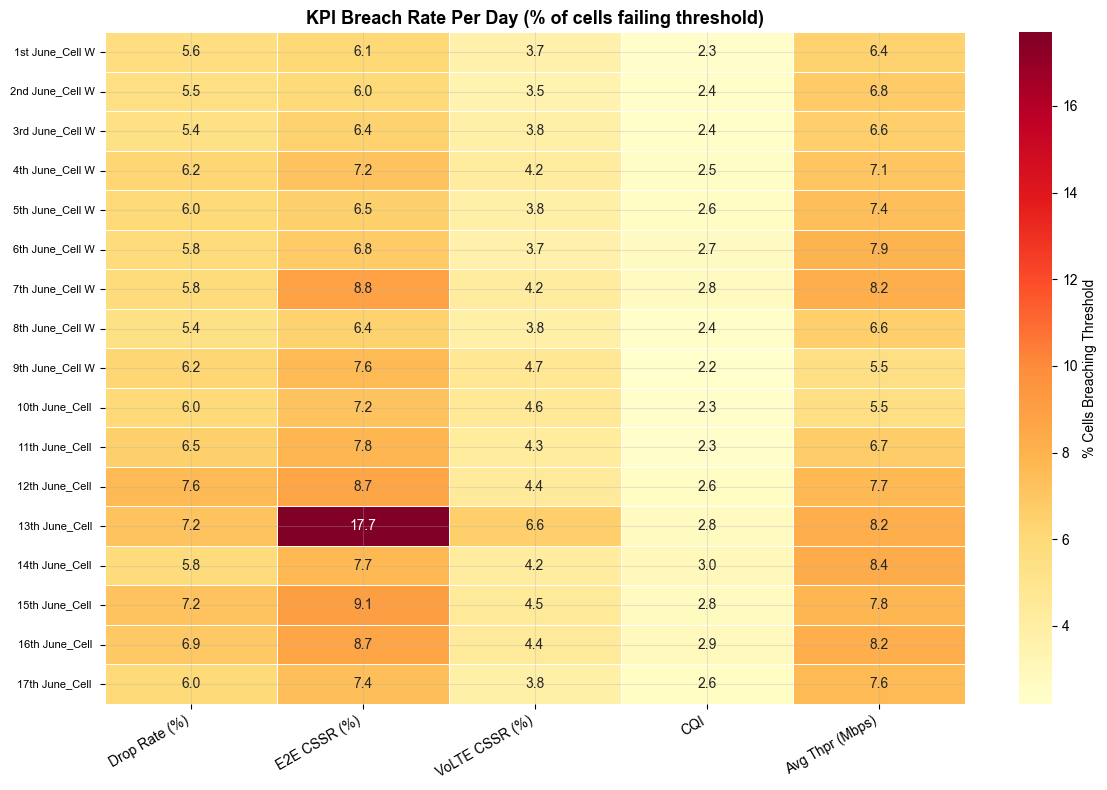

Daily breach rates:

                        Drop Rate (%)  E2E CSSR (%)  VoLTE CSSR (%)  CQI  Avg Thpr (Mbps)
1st June_Cell Wise_4G             5.6           6.1             3.7  2.3              6.4
2nd June_Cell Wise_4G             5.5           6.0             3.5  2.4              6.8
3rd June_Cell Wise_4G             5.4           6.4             3.8  2.4              6.6
4th June_Cell Wise_4G             6.2           7.2             4.2  2.5              7.1
5th June_Cell Wise_4G             6.0           6.5             3.8  2.6              7.4
6th June_Cell Wise_4G             5.8           6.8             3.7  2.7              7.9
7th June_Cell Wise_4G             5.8           8.8             4.2  2.8              8.2
8th June_Cell Wise_4G             5.4           6.4             3.8  2.4              6.6
9th June_Cell Wise_4G             6.2           7.6             4.7  2.2              5.5
10th June_Cell Wise_4G            6.0           7.2             4.6  2.3       

In [10]:
# Cell 10 – What % of cells breach each KPI threshold per day

breach_matrix = pd.DataFrame(index=sheet_names,
                              columns=KPI_LABELS)

for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    for day in sheet_names:
        day_data = pd.to_numeric(
            df[df["Day"] == day][col], errors="coerce"
        ).dropna()
        if len(day_data) == 0:
            breach_matrix.loc[day, cfg["label"]] = 0
            continue
        if cfg["direction"] == "high":
            pct = (day_data > cfg["threshold"]).mean() * 100
        else:
            pct = (day_data < cfg["threshold"]).mean() * 100
        breach_matrix.loc[day, cfg["label"]] = round(pct, 1)

breach_matrix = breach_matrix.apply(pd.to_numeric, errors="coerce")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    breach_matrix,
    annot     = True,
    fmt       = ".1f",
    cmap      = "YlOrRd",
    linewidths= 0.5,
    ax        = ax,
    cbar_kws  = {"label": "% Cells Breaching Threshold"}
)
ax.set_title("KPI Breach Rate Per Day (% of cells failing threshold)",
             fontweight="bold", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha="right")
ax.set_yticklabels(
    [s[:15] for s in sheet_names],
    rotation=0, fontsize=8
)
plt.tight_layout()
plt.savefig("../outputs/eda_breach_rate_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Daily breach rates:\n")
print(breach_matrix.to_string())

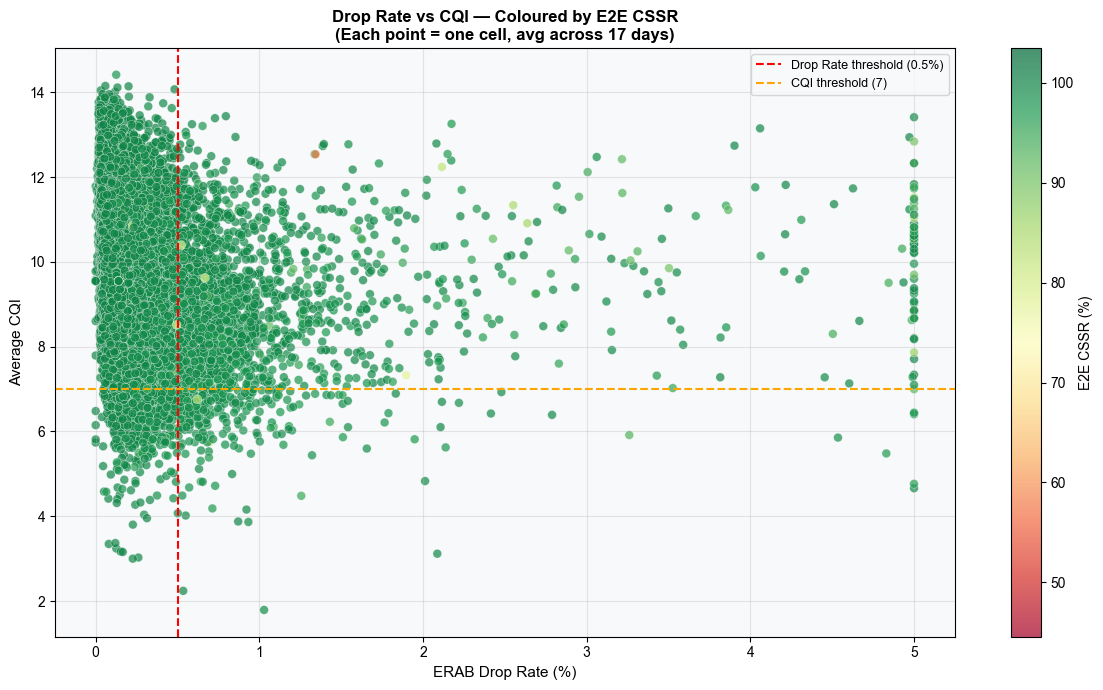

✅ Saved → outputs/eda_scatter_drop_cqi.png


In [11]:
# Cell 11 – Scatter: Drop Rate vs CQI coloured by E2E CSSR
# Shows relationships between KPIs at cell level

drop_col  = "ERAB Drop Rate_Radio_Nokia_VeMr"
cqi_col   = "Average CQI_Nokia_VeMr"
e2e_col   = "E2E Call Setup Success Rate_Nokia_VeMr"

cols_needed = [drop_col, cqi_col, e2e_col, "Short_Cell"]
cols_needed = [c for c in cols_needed if c in df.columns]

scatter_df = df[cols_needed].copy()
for col in [drop_col, cqi_col, e2e_col]:
    if col in scatter_df.columns:
        scatter_df[col] = pd.to_numeric(
            scatter_df[col], errors="coerce"
        )

# Cell average
scatter_df = (scatter_df.groupby("Short_Cell")
              .mean()
              .reset_index()
              .dropna())

# Clip extremes for better scatter
scatter_df[drop_col] = scatter_df[drop_col].clip(upper=5)

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    scatter_df[drop_col],
    scatter_df[cqi_col],
    c      = scatter_df[e2e_col] if e2e_col in scatter_df.columns
             else "#2E75B6",
    cmap   = "RdYlGn",
    alpha  = 0.7,
    s      = 40,
    edgecolors = "white",
    linewidth  = 0.3
)

if e2e_col in scatter_df.columns:
    plt.colorbar(sc, ax=ax, label="E2E CSSR (%)")

ax.axvline(0.5, color="red", linestyle="--",
           linewidth=1.5, label="Drop Rate threshold (0.5%)")
ax.axhline(7.0, color="orange", linestyle="--",
           linewidth=1.5, label="CQI threshold (7)")

ax.set_xlabel("ERAB Drop Rate (%)", fontsize=11)
ax.set_ylabel("Average CQI", fontsize=11)
ax.set_title("Drop Rate vs CQI — Coloured by E2E CSSR\n"
             "(Each point = one cell, avg across 17 days)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/eda_scatter_drop_cqi.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/eda_scatter_drop_cqi.png")

In [12]:
# Cell 12 – EDA Summary printout

print("=" * 60)
print("EDA SUMMARY — Vi PJB 4G Network")
print("=" * 60)
print(f"\nData Period    : {df['Day'].nunique()} days")
print(f"Unique Cells   : {df['Short_Cell'].nunique()}")
print(f"Total Records  : {len(df):,}")

print(f"\n{'─'*60}")
print("KPI HEALTH OVERVIEW")
print(f"{'─'*60}")
print(f"{'KPI':<20} {'Mean':>8} {'Threshold':>10} "
      f"{'Breach %':>10} {'Status':>10}")
print(f"{'─'*60}")

for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    data = pd.to_numeric(df[col], errors="coerce").dropna()
    mean = data.mean()
    if cfg["direction"] == "high":
        breach_pct = (data > cfg["threshold"]).mean() * 100
        status = "⚠️  BAD" if mean > cfg["threshold"] else "✅ OK"
    else:
        breach_pct = (data < cfg["threshold"]).mean() * 100
        status = "⚠️  BAD" if mean < cfg["threshold"] else "✅ OK"
    print(f"  {cfg['label']:<18} {mean:>8.2f} "
          f"{cfg['threshold']:>10} {breach_pct:>9.1f}% {status:>10}")

print(f"\n{'─'*60}")
print("FILES SAVED")
print(f"{'─'*60}")
outputs = [
    "eda_kpi_distributions.png",
    "eda_daily_kpi_trend.png",
    "eda_kpi_correlation.png",
    "eda_kpi_boxplots.png",
    "eda_worst_cells_per_kpi.png",
    "eda_missing_values.png",
    "eda_breach_rate_heatmap.png",
    "eda_scatter_drop_cqi.png",
]
for f in outputs:
    path   = f"../outputs/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists}  {f}")

EDA SUMMARY — Vi PJB 4G Network

Data Period    : 17 days
Unique Cells   : 51359
Total Records  : 842,125

────────────────────────────────────────────────────────────
KPI HEALTH OVERVIEW
────────────────────────────────────────────────────────────
KPI                      Mean  Threshold   Breach %     Status
────────────────────────────────────────────────────────────
  Drop Rate (%)          0.22        0.5       6.2%       ✅ OK
  E2E CSSR (%)          99.56       99.0       8.0%       ✅ OK
  VoLTE CSSR (%)        99.63       99.0       4.2%       ✅ OK
  CQI                    9.61        7.0       2.6%       ✅ OK
  Avg Thpr (Mbps)       10.07        3.0       7.2%       ✅ OK

────────────────────────────────────────────────────────────
FILES SAVED
────────────────────────────────────────────────────────────


NameError: name 'os' is not defined